In [1]:
from astropy.table import Table
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
import pandas as pd
from astropy.wcs import WCS
from astropy.time import Time
from astropy.coordinates import SkyCoord, EarthLocation, AltAz, get_sun
import astropy.units as u
from scipy.signal import savgol_filter



table = Table.read("scans_db.ecsv")
print(table)


  file_path   ...                    Image data                  
------------- ... -----------------------------------------------
20250130/FITS ...                                            None
20250130/FITS ...                                            None
20250130/FITS ...                                            None
20250130/FITS ...                                            None
20250130/FITS ...                                            None
20250130/FITS ...                                            None
20250131/FITS ...                                            None
20250204/FITS ...                                            None
20250204/FITS ... 20250204-093526_IMAGE-GRAD300-AZEL_01#_01#.fits
20250204/FITS ...                                            None
          ... ...                                             ...
20250212/FITS ...                                            None
20250212/FITS ...  20250212-183034_IMAGE-PROJ01-CASA_01#_01#.fits
20250213/F

In [2]:
table

file_path,name,size,date,type,proj,source,object,ra,dec,date-obs,date-end,azimuth,elevation,comment,Image data
str13,str49,int64,Time,str8,str7,str4,str4,float64,float64,Time,Time,float64,float64,str1,object
20250130/FITS,20250130-152816_SPECTRUM-PROJ01-MOON_04#_01#.fits,258420,2025-01-30 15:28:16,SPECTRUM,PROJ01,MOON,moon,21.9231973668008,-15.5926157617175,2025-01-30T15:28:16.000,2025-01-30T15:31:37.000,--,--,--,None
20250130/FITS,20250130-153331_SPECTRUM-PROJ01-CASA_05#_01#.fits,258420,2025-01-30 15:33:31,SPECTRUM,PROJ01,CASA,casa,23.3907268031139,58.813472819952,2025-01-30T15:33:31.000,2025-01-30T15:36:55.000,--,--,--,None
20250130/FITS,20250130-154009_IMAGE-PROJ01-CYGA_01#_01#.fits,5778,2025-01-30 15:40:09,IMAGE,PROJ01,CYGA,cyga,19.9926533219552,40.7342773176912,2025-01-30T15:40:09.000,2025-01-30T15:42:20.000,--,--,--,None
20250130/FITS,20250130-154309_IMAGE-PROJ01-CYGA_01#_01#.fits,6098,2025-01-30 15:43:09,IMAGE,PROJ01,CYGA,cyga,19.9926874185037,40.7320275857824,2025-01-30T15:43:09.000,2025-01-30T16:38:53.000,--,--,--,None
20250130/FITS,20250130-192321_IMAGE-PROJ01-TAUA_01#_01#.fits,6098,2025-01-30 19:23:21,IMAGE,PROJ01,TAUA,taua,5.57633252862212,22.0050198835981,2025-01-30T19:23:21.000,2025-01-30T19:33:25.000,--,--,--,None
20250130/FITS,20250130-193656_IMAGE-PROJ01-AZEL_01#_01#.fits,8802,2025-01-30 19:36:56,IMAGE,PROJ01,AZEL,azel,5.82852564405692,22.0141753936206,2025-01-30T19:36:56.000,2025-01-31T07:10:28.000,--,--,--,None
20250131/FITS,20250131-071839_IMAGE-PROJ01-AZEL_01#_01#.fits,8802,2025-01-31 07:18:39,IMAGE,PROJ01,AZEL,azel,19.9991365468361,40.7324513984007,2025-01-31T07:18:39.000,2025-01-31T13:31:23.000,--,--,--,None
20250204/FITS,20250204-093408_IMAGE-GRAD300-SUN_01#_01#.fits,8802,2025-02-04 09:34:08,IMAGE,GRAD300,SUN,sun,21.2197584323976,-16.0963659305441,2025-02-04T09:34:08.000,2025-02-04T09:35:16.000,--,--,--,None
20250204/FITS,20250204-093521_TPI-GRAD300-AZEL_01#_01#.fits,992016,2025-02-04 09:35:21,TPI,GRAD300,AZEL,azel,21.2197122975359,-16.0924326624407,2025-02-04T09:35:21.000,2025-02-04T11:09:20.000,157.45,26.575,--,20250204-093526_IMAGE-GRAD300-AZEL_01#_01#.fits


In [3]:
ra = table["ra"].data

dec = table["dec"].data





In [4]:
print(len(ra), len(dec))
print(len(table))



81 81
81


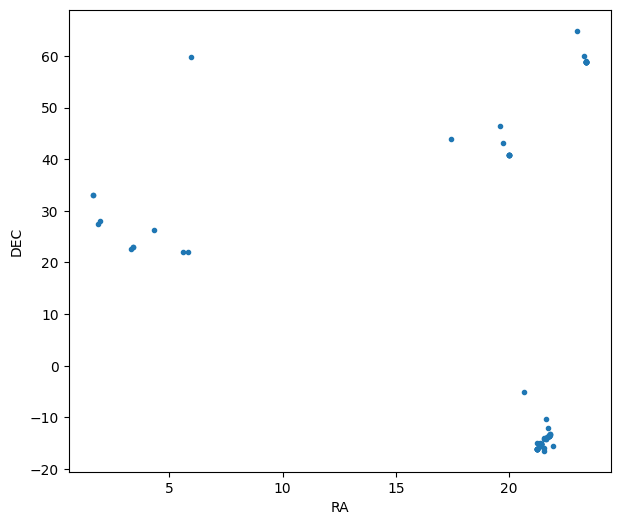

In [5]:
plt.figure(figsize=(7,6))
plt.plot(ra,dec, '.')
plt.xlabel("RA")
plt.ylabel("DEC")
# plt.legend()
plt.savefig("plots/map.png")
plt.show()



Filename: GRAD-300/GRAD-300/20250212/FITS/20250212-083051_SPECTRUM-GRAD300-SUN_01#_01#.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      14   ()      
  1                1 BinTableHDU     85   3R x 11C   ['1D', '1D', '1D', '1D', '1D', '1D', '1D', '1024K', '1024K', '4A', '16A']   


DIAMETER =                    3  / TELESCOPE diameter                            [astropy.io.fits.card]
DIAMETER =                    0  / TELESCOPE diameter                            [astropy.io.fits.card]


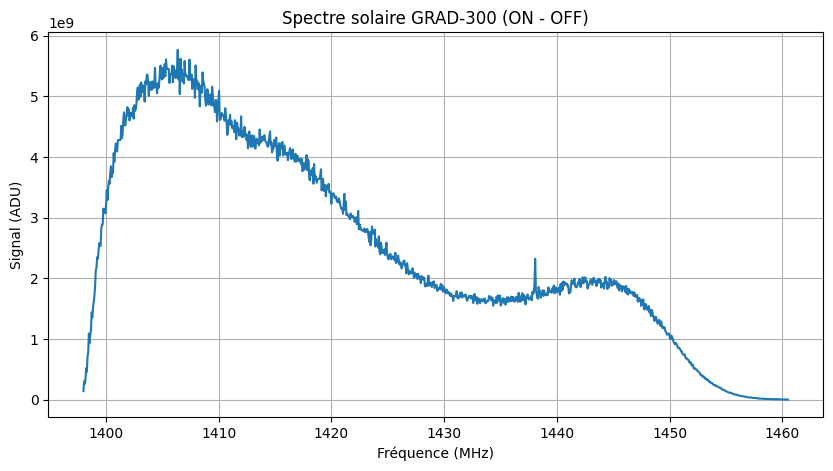

In [6]:



fits_spec_sun = r"GRAD-300/GRAD-300/20250212/FITS/20250212-083051_SPECTRUM-GRAD300-SUN_01#_01#.fits"
fits_tpi_sun = r"GRAD-300/GRAD-300/20250212/FITS/20250212-083213_TPI-GRAD300-SUN_01#_01#.fits"
fits_img_sun = r"GRAD-300/GRAD-300/20250212/FITS/20250212-083216_IMAGE-GRAD300-SUN_01#_01#.fits"




with fits.open(fits_spec_sun) as hdul:
    table = hdul[1].data
    hdul.info()

with fits.open(fits_tpi_sun) as hdultpi:
    table_tpi = hdultpi[1].data


# Extraire les lignes
on  = table[table['STATUS'] == 'on'][0]
off = table[table['STATUS'] == 'off'][0]
cal = table[table['STATUS'] == 'cal'][0]


left_on  = on['LEFT_POL']
right_on = on['RIGHT_POL']

left_off  = off['LEFT_POL']
right_off = off['RIGHT_POL']


spec_on  = left_on  + right_on
spec_off = left_off + right_off


spec_sun = spec_on - spec_off


basefreq = 1.398e9
bandwidth = 62.5e6
nchan = 1024

freq = basefreq + np.linspace(0, bandwidth, nchan)


plt.figure(figsize=(10,5))
plt.plot(freq/1e6, spec_sun)
plt.xlabel("Fréquence (MHz)")
plt.ylabel("Signal (ADU)")
plt.title("Spectre solaire GRAD-300 (ON - OFF)")
plt.grid()
plt.show()








In [7]:
print(on)
print(right_on)

(np.float64(2460718.8547987267), np.float64(128.87), np.float64(16.63), np.float64(-0.016046273196081984), np.float64(-0.005123482227233467), np.float64(41.33419804566281), np.float64(-44.99444768143367), array([ 40208,  49287, 109671, ..., 587312, 700975,      0],
      shape=(1024,), dtype='>i8'), array([149440076, 305870915, 282486537, ...,  41063640,  38783521,
               0], shape=(1024,), dtype='>i8'), 'on', '         SPC 000')
[149440076 305870915 282486537 ...  41063640  38783521         0]


In [8]:
Table.read(fits_tpi_sun)

JD,Azimuth,Elevation,Az_Offset,El_Offset,Gal_Long,Gal_Lat,LEFT_POL,RIGHT_POL,LEFT_FILT,RIGHT_FILT,BBC09u,BBC10u,BBC11u,BBC12u,BBC13u,BBC14u,BBC15u,BBC16u,CAL,MARKER
d,deg,deg,deg,deg,deg,deg,ct,ct,ct,ct,ct,ct,ct,ct,ct,ct,ct,ct,,
float64,float64,float64,float64,float64,float64,float64,int32,int32,int32,int32,int32,int32,int32,int32,int32,int32,int32,int32,bytes4,bytes16
2460718.855715625,129.14,16.81,-0.009092275050790022,-0.009564986116973984,41.323766692247496,-44.99570623934987,9,17682,0,18617,28225,33535,24076,17336,11847,13614,10732,1910,OFF,TPI 000
2460718.855720602,129.14,16.81,-0.012554350764503397,-0.011895327943879153,41.32622646654497,-44.99937651334081,9,17730,0,18693,28708,33461,24119,17347,11849,13646,10740,1903,OFF,TPI 001
2460718.8557251156,129.14,16.81,-0.012554350764503397,-0.011895327943879153,41.32622646654497,-44.99937651334081,9,17683,0,18627,28383,33468,24029,17311,11861,13591,10803,1913,OFF,TPI 002
2460718.855730544,129.14,16.81,-0.012554350764503397,-0.011895327943879153,41.32622646654497,-44.99937651334081,9,17704,0,18638,28244,33658,24033,17275,11843,13654,10804,1911,OFF,TPI 003
2460718.8557357406,129.15,16.82,-0.016014905526333223,-0.014225110266657737,41.328686467229986,-45.00304676426877,9,17696,0,18647,28491,33464,24085,17334,11783,13609,10784,1904,OFF,TPI 004
2460718.855739722,129.15,16.82,-0.016014905526333223,-0.014225110266657737,41.328686467229986,-45.00304676426877,9,17659,0,18580,28111,33412,24041,17358,11833,13605,10790,1911,OFF,TPI 005
2460718.8557437733,129.16,16.82,-0.009477384655440346,-0.006555262627387037,41.32635282842016,-44.99329532724939,9,17661,0,18588,28206,33412,23997,17381,11783,13669,10706,1904,OFF,TPI 006
2460718.855754167,129.16,16.82,0.0005226153445505588,-0.006555262627387037,41.3170413186429,-44.99224003431927,9,17688,0,18631,28384,33481,23996,17397,11839,13612,10729,1916,OFF,TPI 007


In [9]:
Table.read(fits_spec_sun)


JD,Azimuth,Elevation,Az_Offset,El_Offset,Gal_Long,Gal_Lat,LEFT_POL,RIGHT_POL,STATUS,MARKER
d,deg,deg,deg,deg,deg,deg,ct,ct,,
float64,float64,float64,float64,float64,float64,float64,int64[1024],int64[1024],bytes4,bytes16
2460718.8547987267,128.87,16.63,-0.016046273196081984,-0.005123482227233467,41.33419804566281,-44.99444768143367,40208 .. 0,149440076 .. 0,on,SPC 000
2460718.8549398957,141.54,16.66,12.622529777449245,-0.023185460787765066,28.1844619321296,-37.92004589720303,13209 .. 0,8054504 .. 0,off,SPC 001
2460718.854977199,141.55,16.66,12.622169974095414,-0.010198668938546263,28.19735241015525,-37.909840494840175,-27512 .. 0,-6266884 .. 0,cal,SPC 002


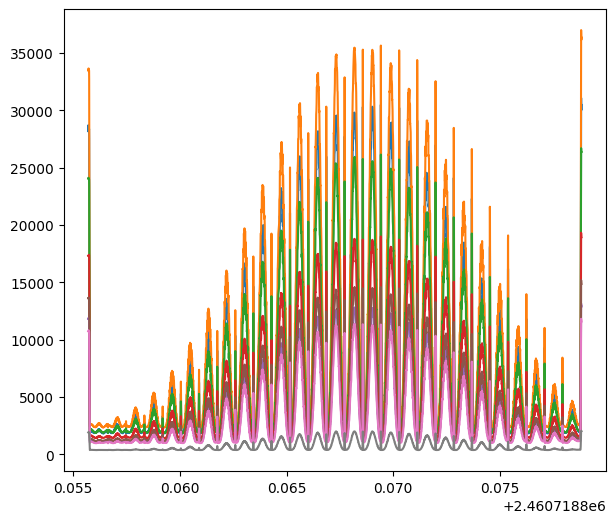

In [10]:
plt.figure(figsize=(7,6))
plt.plot(table_tpi['JD'], table_tpi['BBC09u'])
plt.plot(table_tpi['JD'], table_tpi['BBC10u'])
plt.plot(table_tpi['JD'], table_tpi['BBC11u'])
plt.plot(table_tpi['JD'], table_tpi['BBC12u'])
plt.plot(table_tpi['JD'], table_tpi['BBC13u'])
plt.plot(table_tpi['JD'], table_tpi['BBC14u'])
plt.plot(table_tpi['JD'], table_tpi['BBC15u'])
plt.plot(table_tpi['JD'], table_tpi['BBC16u'])


plt.show()

In [11]:
header_img = fits.getheader(fits_img_sun)
header_tpi = fits.getheader(fits_tpi_sun, 1)

DIAMETER =                     0  / TELESCOPE diameter                           [astropy.io.fits.card]


In [12]:
print(header_img)

SIMPLE  =                    T / Standard FITS Format                           BITPIX  =                   16 / 16 bits ASCII                                  NAXIS   =                    2 / No image data                                  NAXIS1  =                   27 / Bytes per row                                  NAXIS2  =                   27 / NAXIS2 is ydimension of table array            EXTEND  =                    F / Extensions are not present                     ORIGIN  = 'RADIOUNIVERSE_PRO'  / Origin of data                                 DATE-OBS= '2025-02-12T08:32:16'         / UTC of start observ                   DATE-END= '2025-02-12T09:05:23'         / UTC of end observ                     HIERARCH Project_Name= 'GRAD300'                                                HIERARCH Scan Tag= '1'                                                          HIERARCH SubScanID= '1'                                                         HIERARCH ScheduleName= ''               

 [astropy.io.fits.verify]


In [13]:


fits_img_sun = r"GRAD-300/GRAD-300/20250212/FITS/20250212-083216_IMAGE-GRAD300-SUN_01#_01#.fits"

with fits.open(fits_img_sun) as hdul:
    hdul.info()
    image = hdul[0].data
    header = hdul[0].header


Filename: GRAD-300/GRAD-300/20250212/FITS/20250212-083216_IMAGE-GRAD300-SUN_01#_01#.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      60   (27, 27)   int16   


In [14]:
print(image.shape)



(27, 27)


In [15]:
ny, nx = image.shape

y, x = np.indices((ny, nx))
values = image.flatten()
x = x.flatten()
y = y.flatten()


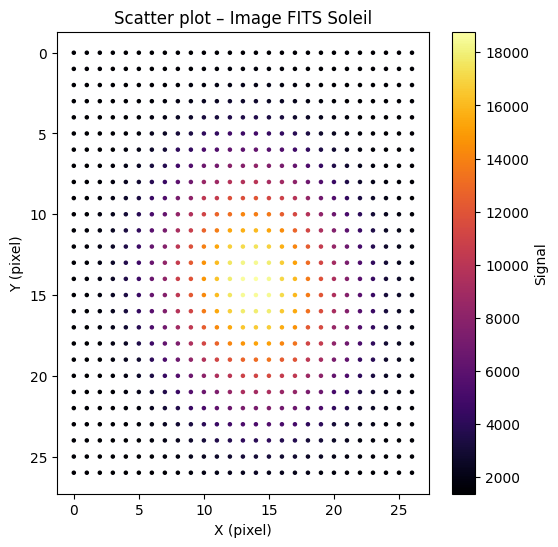

In [16]:
plt.figure(figsize=(6,6))
plt.scatter(
    x, y,
    c=values,
    s=5,               # taille des points
    cmap='inferno'
)

plt.colorbar(label='Signal')
plt.xlabel('X (pixel)')
plt.ylabel('Y (pixel)')
plt.title('Scatter plot – Image FITS Soleil')
plt.gca().invert_yaxis()  # convention image
plt.show()


Set MJD-END to 60718.378738 from DATE-END'. [astropy.wcs.wcs]


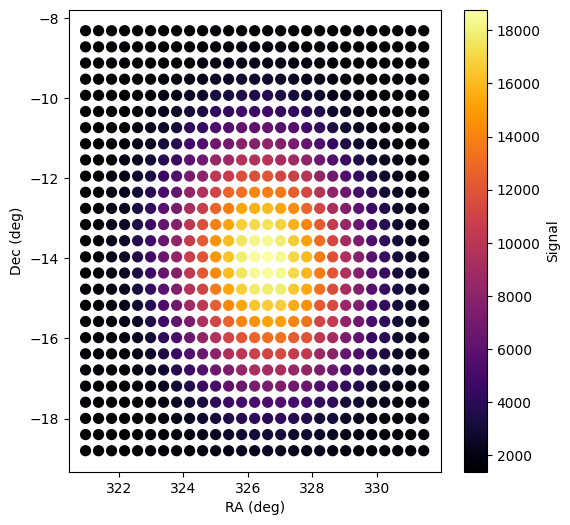

In [17]:

wcs = WCS(header)
ra, dec = wcs.pixel_to_world(x, y).ra.deg, wcs.pixel_to_world(x, y).dec.deg

plt.figure(figsize=(6,6))
plt.scatter(ra, dec, c=values, s=50, cmap='inferno')
plt.xlabel('RA (deg)')
plt.ylabel('Dec (deg)')
plt.colorbar(label='Signal')
plt.show()


In [18]:
print(wcs)

WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA' 'DEC'
CUNIT : 'deg' 'deg'
CRVAL : 326.212222943713 -13.5593213153597
CRPIX : 14.0 14.0
PC1_1 PC1_2  : 1.0 0.0
PC2_1 PC2_2  : 0.0 1.0
CDELT : 0.403376144265431 -0.403376144265431
NAXIS : 27  27


In [19]:
az = table_tpi["Azimuth"]
el = table_tpi["Elevation"]
jd = table_tpi['JD']  

time = Time(jd, format='jd')


location = EarthLocation(
    lat=43.933  * u.deg,
    lon=5.7153 * u.deg,
    height= 654.8 * u.m
)

altaz = AltAz(
    az=az * u.deg,
    alt=el * u.deg,
    location=location,
    obstime=time
)

sky = SkyCoord(altaz)

ra = sky.icrs.ra.deg
dec = sky.icrs.dec.deg



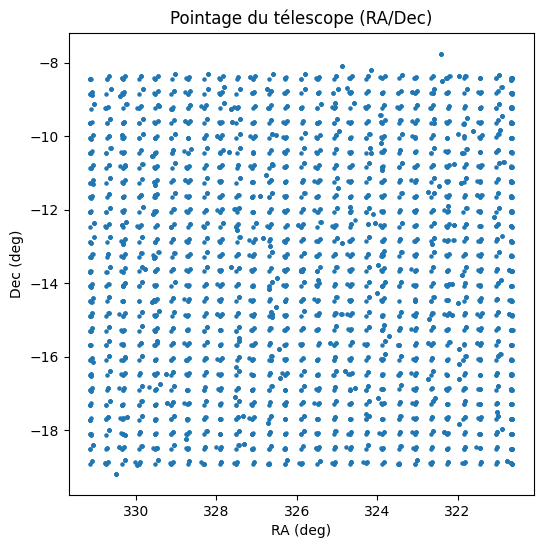

In [20]:


plt.figure(figsize=(6,6))
plt.scatter(ra, dec, s=5)
plt.xlabel("RA (deg)")
plt.ylabel("Dec (deg)")
plt.gca().invert_xaxis()  # convention astro
plt.title("Pointage du télescope (RA/Dec)")
plt.show()


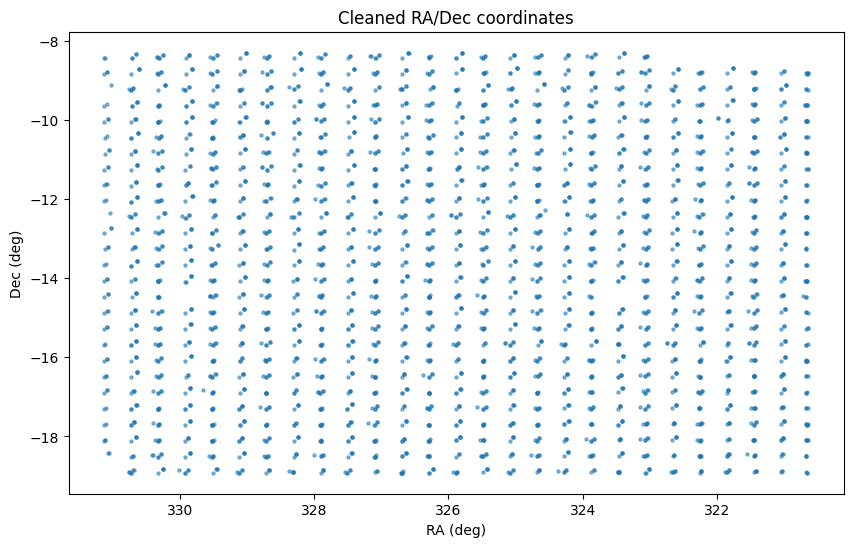

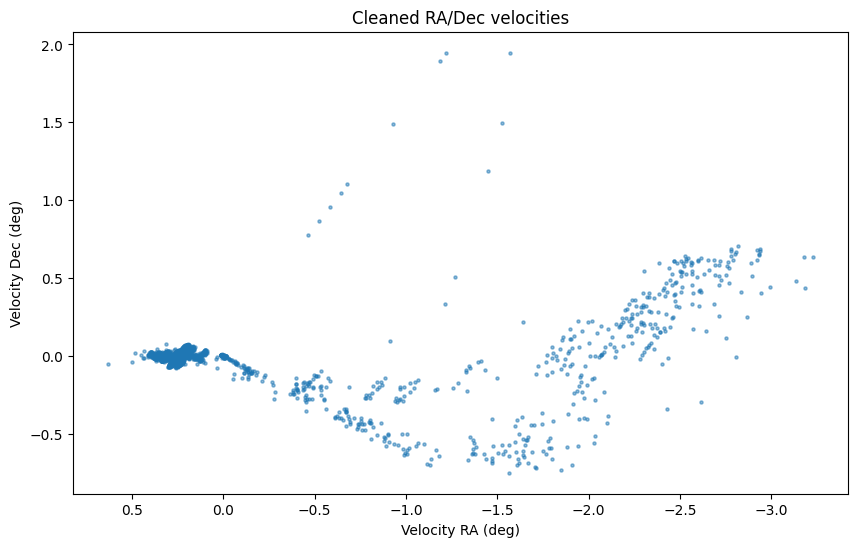

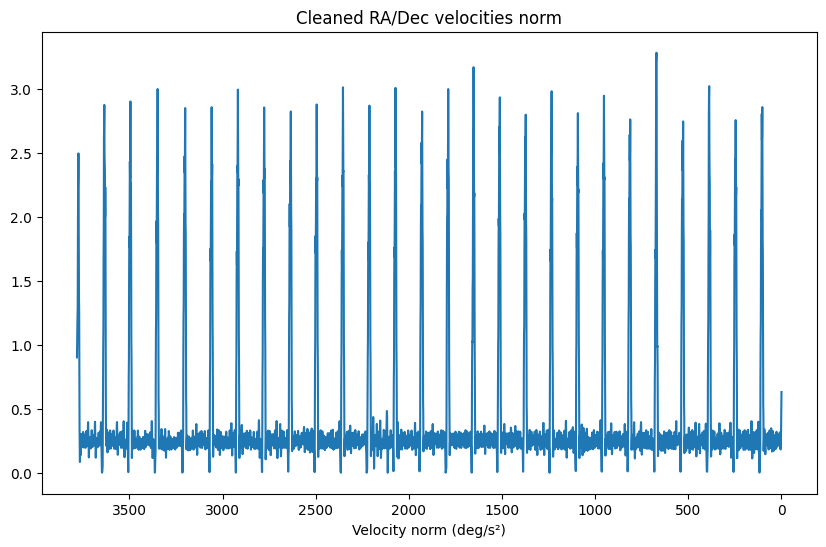

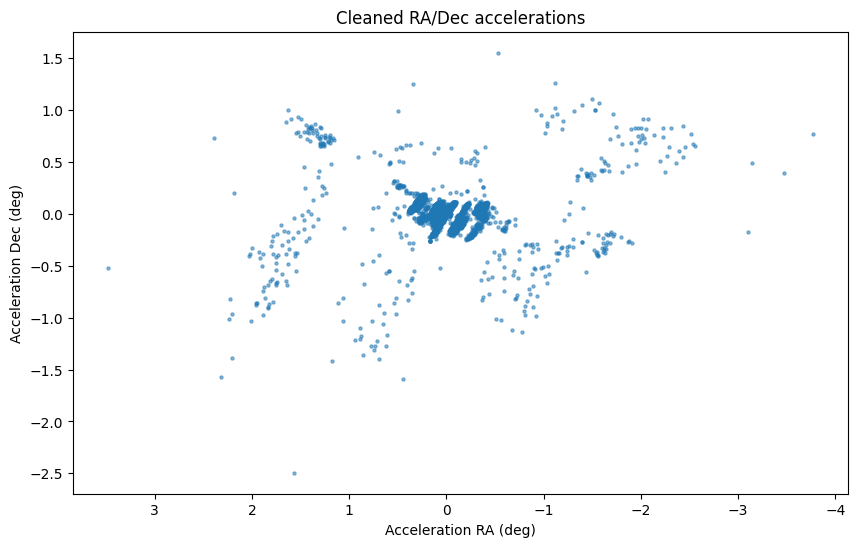

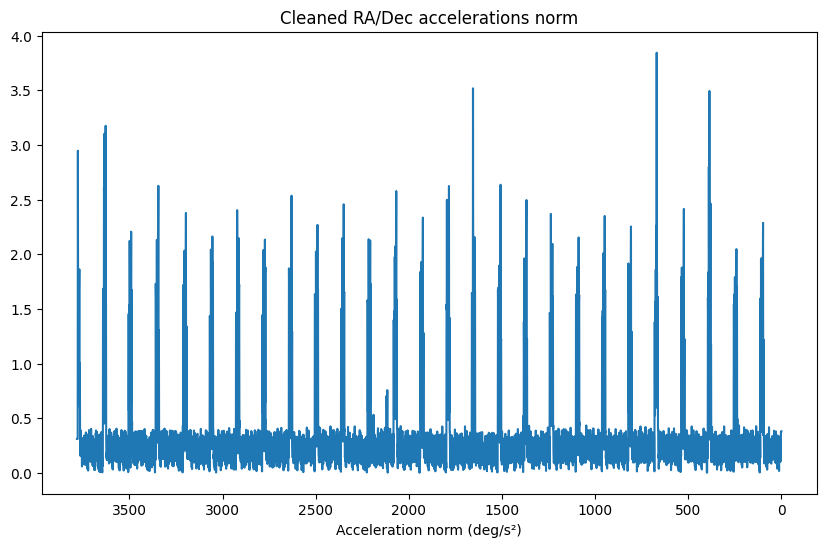

In [111]:
# Application du filtre de Savitzky-Golay
window_length = 7  # doit être impair
polyorder = 2      # ordre du polynôme

# # Filtrage de RA et Dec séparément
# ra_smooth = savgol_filter(ra, window_length, polyorder)
# dec_smooth = savgol_filter(dec, window_length, polyorder)



def sigma_clip_mask_robust(data, k=3):
    data = np.array(data)
    median = np.median(data)
    mad = np.median(np.abs(data - median))
    sigma = 1.4826 * mad  # conversion MAD -> sigma
    
    mask = np.abs(data - median) < k * sigma
    return mask



t = (table_tpi['JD'] - table_tpi['JD'][0]) * 86400

mask_time = t > 1

table_tpi = table_tpi[mask_time]

t_cut = (table_tpi['JD'] - table_tpi['JD'][0]) * 86400
dt = np.median(np.diff(t_cut))

az = table_tpi["Azimuth"]
el = table_tpi["Elevation"]
jd = table_tpi['JD']  

time = Time(jd, format='jd')


location = EarthLocation(
    lat=43.933  * u.deg,
    lon=5.7153 * u.deg,
    height= 654.8 * u.m
)

altaz = AltAz(
    az=az * u.deg,
    alt=el * u.deg,
    location=location,
    obstime=time
)

sky = SkyCoord(altaz)

ra = sky.icrs.ra.deg
dec = sky.icrs.dec.deg


ra_mask = sigma_clip_mask_robust(ra)
dec_mask = sigma_clip_mask_robust(dec)

mask_combined = ra_mask & dec_mask



# Filtrage des vitesses RA et Dec séparément
vit_ra_clipped = savgol_filter(ra[mask_combined], window_length, polyorder, deriv=1, delta=dt)
vit_dec_clipped = savgol_filter(dec[mask_combined], window_length, polyorder, deriv=1, delta=dt)


acc_ra_clipped = savgol_filter(ra[mask_combined], window_length, polyorder, deriv=2, delta=dt)
acc_dec_clipped = savgol_filter(dec[mask_combined], window_length, polyorder, deriv=2, delta=dt)

v_norm = np.sqrt(vit_ra_clipped**2 + vit_dec_clipped**2)
a_norm = np.sqrt(acc_ra_clipped**2 + acc_dec_clipped**2)

mask_vel= sigma_clip_mask_robust(v_norm, k=3)
mask_acc = sigma_clip_mask_robust(a_norm, k=3)

mask = mask_vel & mask_acc

table_tpi_clipped = table_tpi[mask]

# mask = speed > threshold_min


# Vos données
az = table_tpi_clipped["Azimuth"]
el = table_tpi_clipped["Elevation"]
jd = table_tpi_clipped['JD']

time = Time(jd, format='jd')
location = EarthLocation(
    lat=43.933 * u.deg,
    lon=5.7153 * u.deg,
    height=654.8 * u.m
)

altaz = AltAz(
    az=az * u.deg,
    alt=el * u.deg,
    location=location,
    obstime=time
)

sky = SkyCoord(altaz)
ra_clean = sky.icrs.ra.deg
dec_clean = sky.icrs.dec.deg



plt.figure(figsize=(10,6))
plt.scatter(ra_clean, dec_clean, s=5, alpha=0.5)
plt.xlabel("RA (deg)")
plt.ylabel("Dec (deg)")
plt.title("Cleaned RA/Dec coordinates")
plt.gca().invert_xaxis()

plt.figure(figsize=(10,6))
plt.scatter(vit_ra_clipped, vit_dec_clipped, s=5, alpha=0.5)
plt.xlabel("Velocity RA (deg)")
plt.ylabel("Velocity Dec (deg)")
plt.title("Cleaned RA/Dec velocities")
plt.gca().invert_xaxis()


plt.figure(figsize=(10,6))
plt.plot(v_norm)
plt.xlabel("Velocity norm (deg/s²)")

plt.title("Cleaned RA/Dec velocities norm")
plt.gca().invert_xaxis()


plt.figure(figsize=(10,6))
plt.scatter(acc_ra_clipped, acc_dec_clipped, s=5, alpha=0.5)
plt.xlabel("Acceleration RA (deg)")
plt.ylabel("Acceleration Dec (deg)")
plt.title("Cleaned RA/Dec accelerations")
plt.gca().invert_xaxis()


plt.figure(figsize=(10,6))
plt.plot(a_norm)
plt.xlabel("Acceleration norm (deg/s²)")

plt.title("Cleaned RA/Dec accelerations norm")
plt.gca().invert_xaxis()
plt.show()


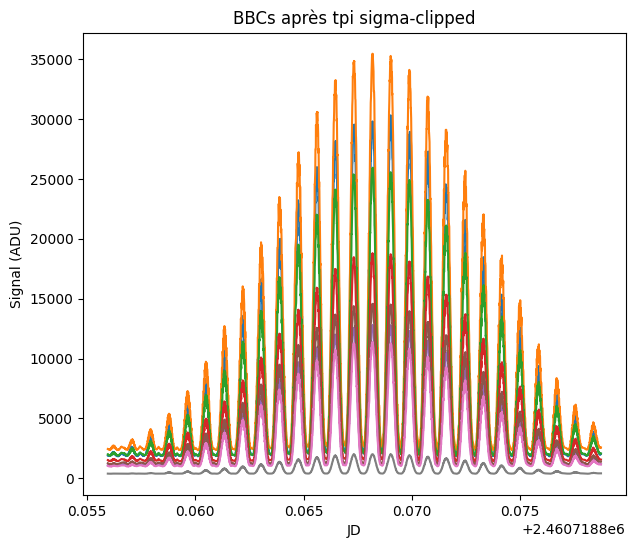

In [107]:
plt.figure(figsize=(7,6))
plt.plot(table_tpi_clipped['JD'], table_tpi_clipped['BBC09u'])
plt.plot(table_tpi_clipped['JD'], table_tpi_clipped['BBC10u'])
plt.plot(table_tpi_clipped['JD'], table_tpi_clipped['BBC11u'])
plt.plot(table_tpi_clipped['JD'], table_tpi_clipped['BBC12u'])
plt.plot(table_tpi_clipped['JD'], table_tpi_clipped['BBC13u'])
plt.plot(table_tpi_clipped['JD'], table_tpi_clipped['BBC14u'])
plt.plot(table_tpi_clipped['JD'], table_tpi_clipped['BBC15u'])
plt.plot(table_tpi_clipped['JD'], table_tpi_clipped['BBC16u'])

plt.xlabel("JD")
plt.ylabel("Signal (ADU)")
plt.title("BBCs après tpi sigma-clipped")
plt.savefig("plots/bbc_tpi_clipped.png")
plt.show()

In [108]:
import pandas as pd

df = pd.DataFrame({bbc: bbc_clean[bbc] for bbc in bbc_list})
print(df.corr())


          BBC09u    BBC10u    BBC11u    BBC12u    BBC13u    BBC14u    BBC15u  \
BBC09u  1.000000  0.999579  0.998292  0.997685  0.995614  0.993915  0.993645   
BBC10u  0.999579  1.000000  0.999354  0.998918  0.997280  0.995749  0.995254   
BBC11u  0.998292  0.999354  1.000000  0.999881  0.998728  0.997218  0.996362   
BBC12u  0.997685  0.998918  0.999881  1.000000  0.999251  0.997884  0.996991   
BBC13u  0.995614  0.997280  0.998728  0.999251  1.000000  0.999391  0.998506   
BBC14u  0.993915  0.995749  0.997218  0.997884  0.999391  1.000000  0.999630   
BBC15u  0.993645  0.995254  0.996362  0.996991  0.998506  0.999630  1.000000   
BBC16u  0.994006  0.995159  0.995689  0.996242  0.997522  0.998763  0.999577   

          BBC16u  
BBC09u  0.994006  
BBC10u  0.995159  
BBC11u  0.995689  
BBC12u  0.996242  
BBC13u  0.997522  
BBC14u  0.998763  
BBC15u  0.999577  
BBC16u  1.000000  


In [ ]:
# freq_list = [f_BBC09, f_BBC10, ..., f_BBC16]  # fréquences centrales de chaque BBC
# spectrum = [np.mean(bbc_clean[bbc]) for bbc in bbc_list]

# plt.plot(freq_list, spectrum, 'o-')
# plt.xlabel("Frequency (MHz)")
# plt.ylabel("Power (ADU)")
# plt.title("Low-resolution solar spectrum from BBCs")
# plt.grid(True)
# plt.show()


NameError: name 'f_BBC09' is not defined

In [23]:
print(off['RIGHT_POL'], len(off['RIGHT_POL']))
print(on['RIGHT_POL'], len(on['RIGHT_POL']))
print(table_tpi_clipped['RIGHT_POL'], len(table_tpi_clipped['RIGHT_POL']), np.sum(table_tpi_clipped['RIGHT_POL']))



[ 8054504  3035169 24901723 ... 37530200 34330215        0] 1024
[149440076 305870915 282486537 ...  41063640  38783521         0] 1024
[17682 17730 17659 ...  1598  1587  1604] 3271 16983935


In [ ]:
left_pol = table['LEFT_POL']
right_pol = table['RIGHT_POL']

print("left pol length:", len(left_pol))
print(left_pol)
print("right pol length:",len(right_pol) )
print(right_pol)

spec = left_pol + right_pol   # spectre total

print("spec length:",len(spec))
#ptet faire la moyenne de chaque BBC pour comparer avec les valeurs de table_tpi
test_bbc09 = np.sum(spec[0:128])
test_bbc10 = np.sum(spec[128:256])

#BBC theorique avec la somme des deux polarisations sur 128 canaux
print("test BBC09:", test_bbc09)
print("test BBC10:", test_bbc10)

print("BBC09u:", np.sum(table_tpi['BBC09u']))
print("BBC10u:", np.sum(table_tpi['BBC10u']))

print("mean BBC09u:", np.sum(table_tpi['BBC09u'])/len(table_tpi['BBC09u']))
print("mean BBC10u:", np.sum(table_tpi['BBC10u'])/len(table_tpi['BBC10u']))


spec_left = left_pol
spec_right = right_pol

test_bbc09_left = np.sum(spec_left[0:128])
test_bbc10_left = np.sum(spec_left[128:256])
test_bbc09_right = np.sum(spec_right[0:128])
test_bbc10_right = np.sum(spec_right[128:256])


#BBC theorique left et right avec la somme des deux polarisations sur 128 canaux
print("test BBC09 left:", test_bbc09_left)
print("test BBC10 left:", test_bbc10_left)

print("test BBC09 right:", test_bbc09_right)
print("test BBC10 right:", test_bbc10_right)

#Comparaison avec les valeurs de table_tpi (moyenne et somme sur le temps de chaque BBC)
print("BBC09u:", np.sum(table_tpi['BBC09u']))
print("BBC10u:", np.sum(table_tpi['BBC10u']))

print("mean BBC09u:", np.sum(table_tpi['BBC09u'])/len(table_tpi['BBC09u']))
print("mean BBC10u:", np.sum(table_tpi['BBC10u'])/len(table_tpi['BBC10u']))

print(test_bbc09_left, test_bbc10_left)
print(test_bbc09_right, test_bbc10_right)


left pol length: 3
[[ 40208  49287 109671 ... 587312 700975      0]
 [ 13209  -5008 142978 ... 617496 685715      0]
 [-27512   -237  59473 ... 598355 665272      0]]
right pol length: 3
[[149440076 305870915 282486537 ...  41063640  38783521         0]
 [  8054504   3035169  24901723 ...  37530200  34330215         0]
 [ -6266884   8342774  45029026 ...  36840758  36040563         0]]
spec length: 3
test BBC09: 3390252063097
test BBC10: 0
BBC09u: 30105436
BBC10u: 35974594
mean BBC09u: 7852.226395409494
mean BBC10u: 9383.044861763172
test BBC09 left: 4398879953
test BBC10 left: 0
test BBC09 right: 3385853183144
test BBC10 right: 0
BBC09u: 30105436
BBC10u: 35974594
mean BBC09u: 7852.226395409494
mean BBC10u: 9383.044861763172
4398879953 0
3385853183144 0


In [34]:
def compute_bbc_blocks(spec, operation, block_size=128):
    bbc = []
    if operation == "sum":
        for i in range(0, 1024, block_size):
            bbc.append(np.sum(spec[i:i+block_size]))
    elif operation == "mean":
        for i in range(0, 1024, block_size):
            bbc.append(np.mean(spec[i:i+block_size]))
    return np.array(bbc)




bbc_on_sum   = compute_bbc_blocks(spec_on, "sum")
bbc_off_sum  = compute_bbc_blocks(spec_off, "sum")
bbc_sun_sum = compute_bbc_blocks(spec_sun, "sum")

bbc_on_mean   = compute_bbc_blocks(spec_on, "mean")
bbc_off_mean  = compute_bbc_blocks(spec_off, "mean")
bbc_sun_mean = compute_bbc_blocks(spec_sun, "mean")


print("BBC ON théorique (sum):", bbc_on_sum)
print("BBC OFF théorique (sum):", bbc_off_sum)
print("BBC SUN théorique (sum):", bbc_sun_sum)

print("BBC ON théorique (mean):", bbc_on_mean)
print("BBC OFF théorique (mean):", bbc_off_mean)
print("BBC SUN théorique (mean):", bbc_sun_mean)



print(abs(table_tpi['JD']- on['JD']))

print(table_tpi['JD'], on['JD'])

print(abs(table_tpi['JD'][-1]- on['JD']))


BBC ON théorique (sum): [551404369883 670806619757 531489394082 337582587222 238756179466
 261250061724 182523047499  19584707533]
BBC OFF théorique (sum): [39076764231 49790212883 43487633605 29871610120 22365994710 24025392784
 18460865721  5996617637]
BBC SUN théorique (sum): [512327605652 621016406874 488001760477 307710977102 216390184756
 237224668940 164062181778  13588089896]
BBC ON théorique (mean): [4.30784664e+09 5.24067672e+09 4.15226089e+09 2.63736396e+09
 1.86528265e+09 2.04101611e+09 1.42596131e+09 1.53005528e+08]
BBC OFF théorique (mean): [3.05287221e+08 3.88986038e+08 3.39747138e+08 2.33371954e+08
 1.74734334e+08 1.87698381e+08 1.44225513e+08 4.68485753e+07]
BBC SUN théorique (mean): [4.00255942e+09 4.85169068e+09 3.81251375e+09 2.40399201e+09
 1.69054832e+09 1.85331773e+09 1.28173580e+09 1.06156952e+08]
[0.0009169  0.00092188 0.00092639 ... 0.0240006  0.02400566 0.02401037]
[2460718.85571562 2460718.8557206  2460718.85572512 ... 2460718.87879933
 2460718.87880439 2460

In [33]:
print(on['JD'])
print(off['JD'])
print(cal['JD'])


2460718.8547987267
2460718.8549398957
2460718.854977199


In [65]:
bbc_list = ['BBC09u','BBC10u','BBC11u','BBC12u',
            'BBC13u','BBC14u','BBC15u','BBC16u']


for bbc in bbc_list:
    
    mean = np.mean(table_tpi[bbc])
    std  = np.std(table_tpi[bbc])
    
    print(bbc, mean, std)

bbc_clean = {}

# masque initial : tout True
mask_global = np.ones(len(table_tpi_clipped), dtype=bool)

for bbc in bbc_list:
    mask_bbc = sigma_clip_mask_robust(table_tpi_clipped[bbc])
    mask_global &= mask_bbc   # cumul logique

for bbc in bbc_list:
    bbc_clean[bbc] = table_tpi_clipped[bbc][mask_global]

bbc_clean['JD'] = table_tpi_clipped['JD'][mask_global]
    
print(bbc_clean)


for bbc in bbc_clean.keys():
    
    mean = np.mean(bbc_clean[bbc])
    std  = np.std(bbc_clean[bbc])
    
    print(bbc, mean, std)
    
    
for bbc in bbc_list:
    mean = np.mean(bbc_clean[bbc])
    std  = np.std(bbc_clean[bbc])
    print(bbc,"std/mean :", std/mean)



BBC09u 7852.226395409494 7462.876107081126
BBC10u 9383.044861763172 8775.913744724654
BBC11u 6859.22848200313 6282.795207772494
BBC12u 4971.746218049035 4530.229429902078
BBC13u 3386.3281168492435 3058.277710377119
BBC14u 3805.6669274908713 3491.1464111934256
BBC15u 2994.6593635889412 2699.630601149482
BBC16u 687.7746478873239 421.3933204755532
{'BBC09u': array([2036, 2096, 2065, ..., 2045, 2000, 2035],
      shape=(2574,), dtype='>i4'), 'BBC10u': array([2641, 2646, 2645, ..., 2565, 2561, 2603],
      shape=(2574,), dtype='>i4'), 'BBC11u': array([2168, 2163, 2172, ..., 2062, 2065, 2075],
      shape=(2574,), dtype='>i4'), 'BBC12u': array([1637, 1639, 1645, ..., 1564, 1555, 1566],
      shape=(2574,), dtype='>i4'), 'BBC13u': array([1217, 1204, 1212, ..., 1177, 1175, 1183],
      shape=(2574,), dtype='>i4'), 'BBC14u': array([1363, 1366, 1367, ..., 1392, 1387, 1393],
      shape=(2574,), dtype='>i4'), 'BBC15u': array([1107, 1104, 1104, ..., 1157, 1155, 1160],
      shape=(2574,), dtype='>

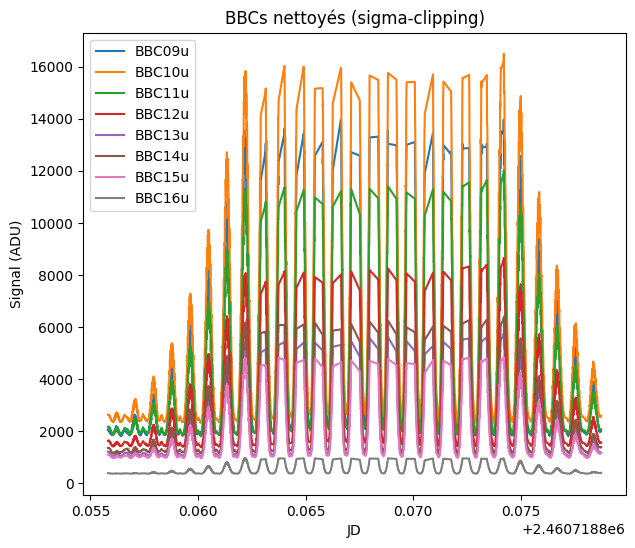

In [66]:
plt.figure(figsize=(7,6))

for bbc in bbc_clean.keys():
    if bbc != 'JD':
        plt.plot(bbc_clean['JD'], bbc_clean[bbc], label=bbc)
plt.xlabel("JD")
plt.ylabel("Signal (ADU)")
plt.title("BBCs nettoyés (sigma-clipping)")
plt.legend()
plt.show()

In [ ]:
# good_bbcs = ['BBC09u','BBC10u','BBC11u','BBC12u',]  # exemple

# right_reconstructed = np.sum(
#     [table_tpi_clipp[bbc] for bbc in good_bbcs],
#     axis=0
# )


In [ ]:
# Extraire les lignes
on  = table_tpi_clipped[table_tpi_clipped['STATUS'] == 'on'][0]
off = table_tpi_clipped[table_tpi_clipped['STATUS'] == 'off'][0]
cal = table_tpi_clipped[table_tpi_clipped['STATUS'] == 'cal'][0]


left_on  = on['LEFT_POL']
right_on = on['RIGHT_POL']

left_off  = off['LEFT_POL']
right_off = off['RIGHT_POL']


spec_on  = left_on  + right_on
spec_off = left_off + right_off


spec_sun = spec_on - spec_off


basefreq = 1.398e9
bandwidth = 62.5e6
nchan = 1024

freq = basefreq + np.linspace(0, bandwidth, nchan)


plt.figure(figsize=(10,5))
plt.plot(freq/1e6, spec_sun)
plt.xlabel("Fréquence (MHz)")
plt.ylabel("Signal (ADU)")
plt.title("Spectre solaire GRAD-300 (ON - OFF)")
plt.grid()
plt.show()

KeyError: "Key 'STATUS' does not exist."

In [ ]:

wcs = WCS(naxis=2)

# Taille image
nx, ny = 27, 27

# Centre image
wcs.wcs.crpix = [14.0, 14.0]

# Coordonnées ciel du centre
wcs.wcs.crval = [326.212222943713, -13.5593213153597]

# Taille pixel (deg / pixel)
wcs.wcs.cdelt = [0.403376144265431, -0.403376144265431]

# Projection
wcs.wcs.ctype = ["RA---TAN", "DEC--TAN"]

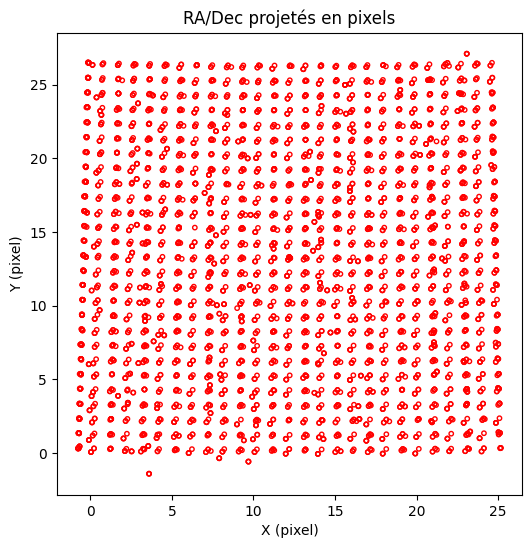

In [ ]:
x_pix,y_pix = wcs.world_to_pixel_values(ra, dec)

from astropy.visualization import simple_norm

# norm = simple_norm(image, stretch='sqrt', percent=99)

plt.figure(figsize=(6,6))
# plt.imshow(image, origin='lower', cmap='gray', norm=norm)
plt.scatter(x_pix, y_pix, s=10, edgecolor='red', facecolor='none')
plt.xlabel("X (pixel)")
plt.ylabel("Y (pixel)")
plt.title("RA/Dec projetés en pixels")
plt.show()


In [ ]:
get_sun(jd)

AttributeError: 'numpy.ndarray' object has no attribute 'scale'